In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

In [2]:
tasks_df = pd.read_csv('02_task_results.csv')
steps_df = pd.read_csv('02_ai_step_log.csv')

data = {
    'tasks': tasks_df,
    'steps': steps_df
}

print(f"Total tasks: {len(data['tasks'])}")
print(f"Total steps: {len(data['steps'])}")

display(data['tasks'].head(3))

Total tasks: 100
Total steps: 972


,runId,timestampStart,timestampEnd,methodName,modelName,seed,experimentCaseId,experimentCobwebsEnabled,experimentCobwebRoomChance,experimentCobwebChancePerFloorTile,...,initialTreeCount,finalTreeCount,treesCut,stepsTaken,apiCalls,bumpCount,doorInteractionCount,corridorTraversalCount,discoveredRoomCount,durationSeconds
0,20260605_150138_757_seed31_case5_prompt_memory...,2026-06-05 15:01:38,2026-06-05 15:02:40,prompt_memory_graph,gpt-4.1-mini,31,5,False,0.5,0.4,...,1,0,1,21,21,0,10,11,5,62.19
1,20260605_150326_845_seed31_case5_prompt_memory...,2026-06-05 15:03:26,2026-06-05 15:04:20,prompt_memory_graph_rag,gpt-4.1-mini,31,5,False,0.5,0.4,...,1,0,1,17,17,1,10,5,5,53.21
2,20260606_195032_110_seed31_case5_prompt_memory,2026-06-06 19:50:32,2026-06-06 19:51:32,prompt_memory,gpt-4.1-mini,31,5,False,0.5,0.4,...,1,1,0,20,20,2,4,11,3,60.74


,methodName,Total_Runs,Success_Rate,Method
0,prompt_memory,25,76.0,Object Memory
1,prompt_memory_graph,25,88.0,Graph Memory
2,prompt_memory_graph_rag,25,92.0,Graph + RAG
3,prompt_only,25,76.0,Prompt Only


/tmp/ipykernel_4278/4103312265.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


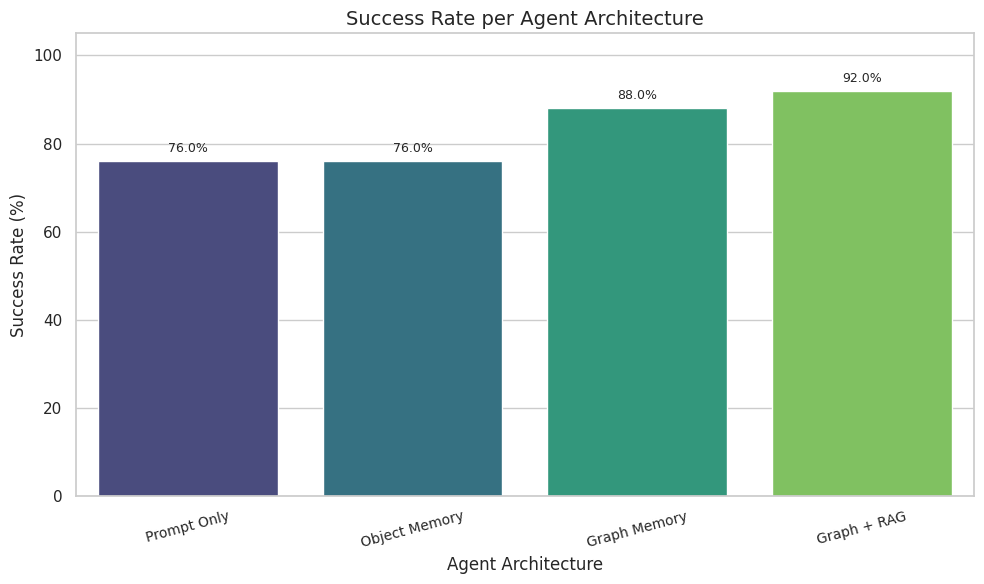

In [13]:
df_tasks = data['tasks'].copy()

method_order = [
    'prompt_only',
    'prompt_memory',
    'prompt_memory_graph',
    'prompt_memory_graph_rag'
]

method_labels = {
    'prompt_only': 'Prompt Only',
    'prompt_memory': 'Object Memory',
    'prompt_memory_graph': 'Graph Memory',
    'prompt_memory_graph_rag': 'Graph + RAG'
}

success_summary = df_tasks.groupby('methodName')['success'].agg(
    Total_Runs='count',
    Success_Rate=lambda x: (x.mean() * 100).round(2)
).reset_index()

success_summary['Method'] = success_summary['methodName'].map(method_labels)

plot_order = [
    method_labels[m] for m in method_order
    if m in success_summary['methodName'].values
]

display(success_summary)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=success_summary,
    x='Method',
    y='Success_Rate',
    palette='viridis',
    order=plot_order
)

plt.title('Success Rate per Agent Architecture', fontsize=14)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xlabel('Agent Architecture', fontsize=12)

plt.xticks(rotation=15, fontsize=10)
plt.ylim(0, 105)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.savefig("success_rate_per_method.png", dpi=300, bbox_inches="tight")
plt.show()

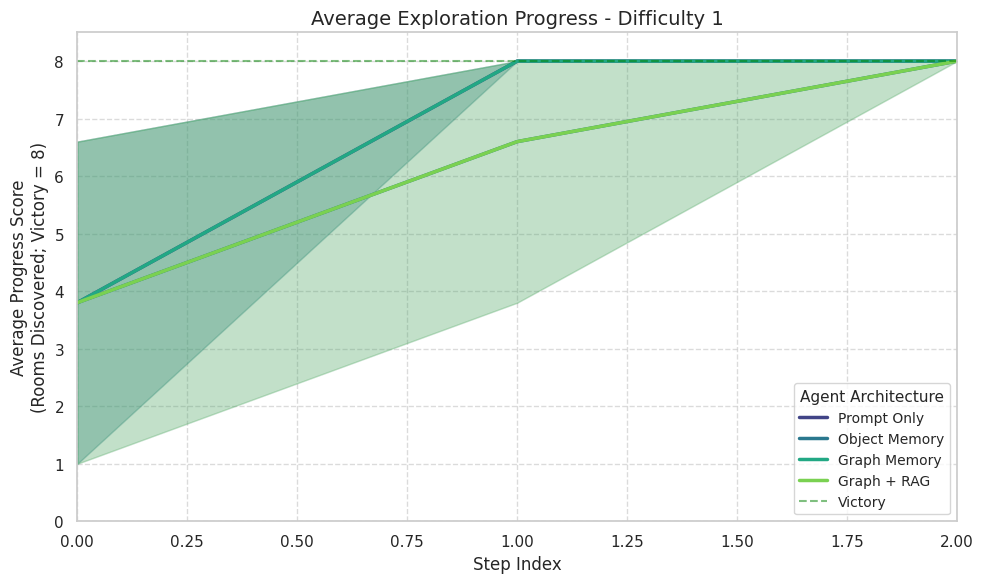

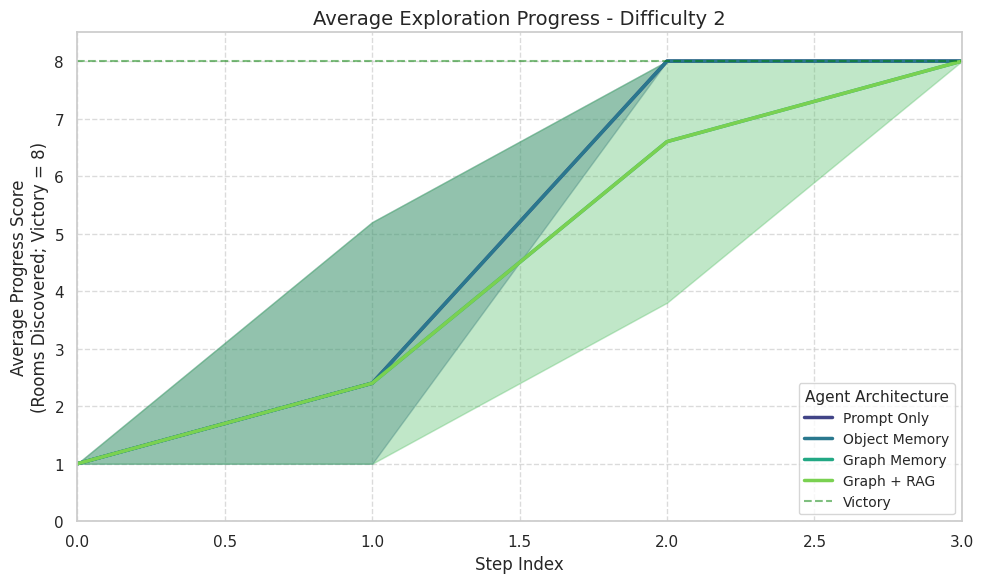

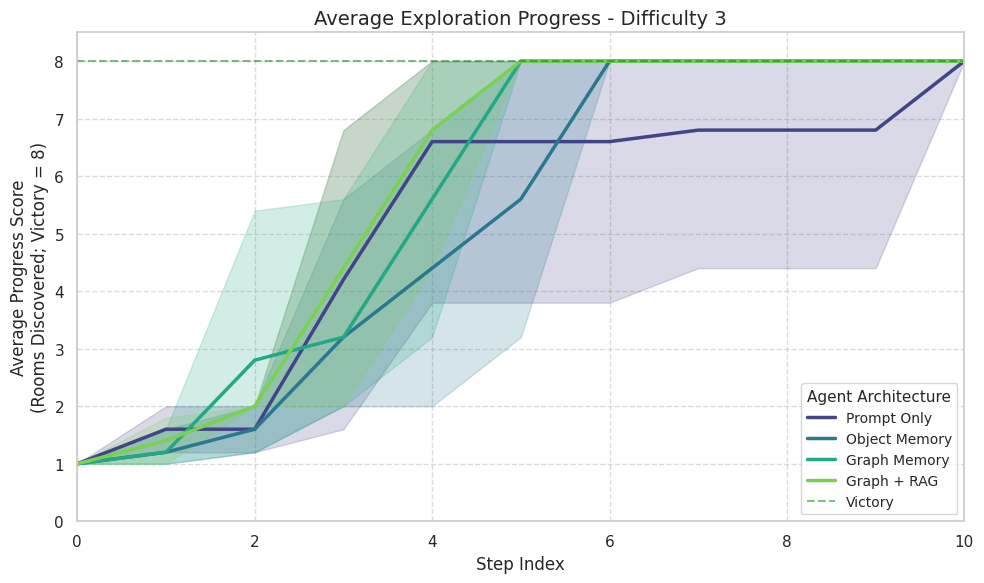

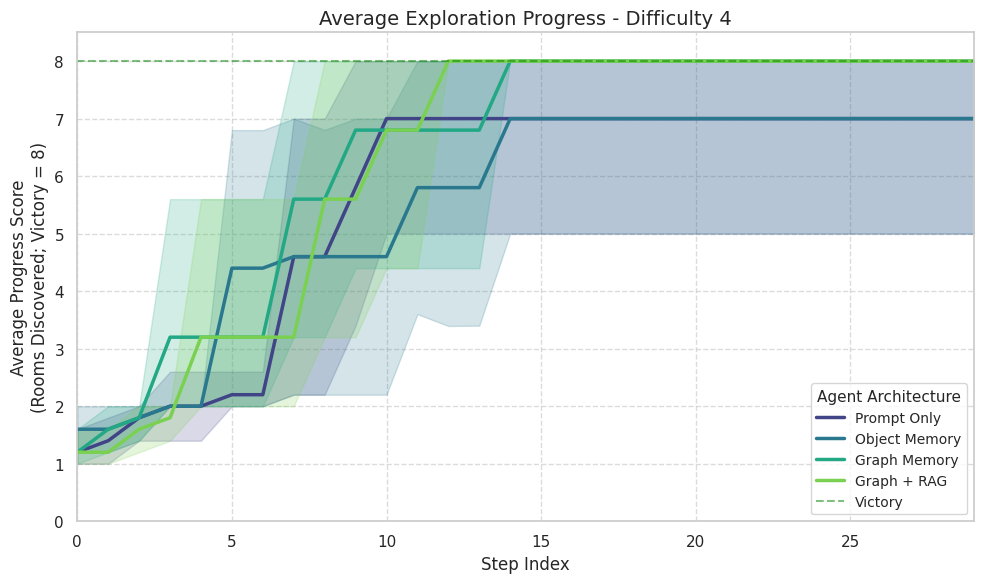

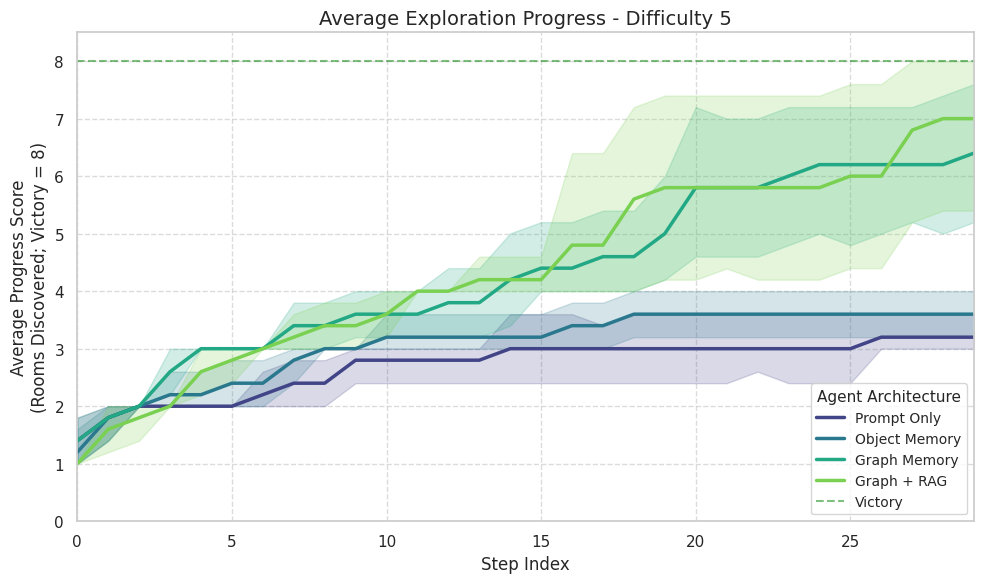

In [4]:
df_tasks = data['tasks'].copy()
df_steps = data['steps'].copy()

method_order = [
    'prompt_only',
    'prompt_memory',
    'prompt_memory_graph',
    'prompt_memory_graph_rag'
]

method_labels = {
    'prompt_only': 'Prompt Only',
    'prompt_memory': 'Object Memory',
    'prompt_memory_graph': 'Graph Memory',
    'prompt_memory_graph_rag': 'Graph + RAG'
}

df_merged = df_steps.merge(
    df_tasks[
        [
            'runId',
            'methodName',
            'seed',
            'experimentCaseId',
            'success',
            'generatedRoomCount'
        ]
    ],
    on='runId',
    how='left'
)

df_merged['Method'] = df_merged['methodName'].map(method_labels)

all_cases = sorted(df_merged['experimentCaseId'].dropna().unique())

for case_id in all_cases:
    df_case = df_merged[df_merged['experimentCaseId'] == case_id].copy()

    if df_case.empty:
        continue

    global_max_steps = int(df_case['stepIndex'].max())

    df_case['explorationScore'] = df_case['discoveredRoomsAfterStep']

    max_rooms = int(df_case['generatedRoomCount'].max())
    victory_score = max_rooms + 1

    successful_runs = df_case[df_case['success'] == True]

    if not successful_runs.empty:
        idx_successful_last_steps = successful_runs.groupby('runId')['stepIndex'].idxmax()
        df_case.loc[idx_successful_last_steps, 'explorationScore'] = victory_score

    padded_frames = []

    for run_id, group in df_case.groupby('runId'):
        group = group.set_index('stepIndex').reindex(range(global_max_steps + 1))

        group['explorationScore'] = group['explorationScore'].ffill()
        group['methodName'] = group['methodName'].ffill().bfill()
        group['Method'] = group['methodName'].map(method_labels)
        group['runId'] = run_id

        group = group.reset_index().rename(columns={'index': 'stepIndex'})
        padded_frames.append(group)

    df_padded = pd.concat(padded_frames, ignore_index=True)

    plot_order = [
        method_labels[m] for m in method_order
        if m in df_padded['methodName'].dropna().unique()
    ]

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df_padded,
        x='stepIndex',
        y='explorationScore',
        hue='Method',
        hue_order=plot_order,
        palette='viridis',
        linewidth=2.5,
        errorbar=("ci", 95)
    )

    plt.title(
        f'Average Exploration Progress - Difficulty {case_id}',
        fontsize=14
    )

    plt.ylabel(
        f'Average Progress Score\n(Rooms Discovered; Victory = {victory_score})',
        fontsize=12
    )
    plt.xlabel('Step Index', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0, global_max_steps)
    plt.ylim(0, victory_score + 0.5)

    plt.axhline(
        y=victory_score,
        color='green',
        linestyle='--',
        alpha=0.5,
        label='Victory'
    )

    plt.legend(title='Agent Architecture', fontsize=10, title_fontsize=11)

    plt.tight_layout()

    filename = f"exploration_progress_difficulty_{case_id}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

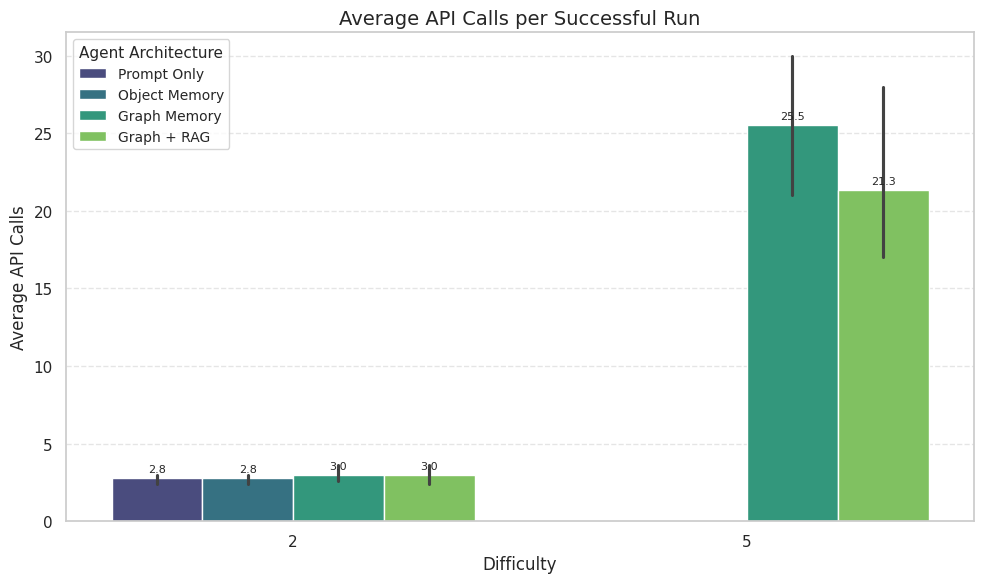

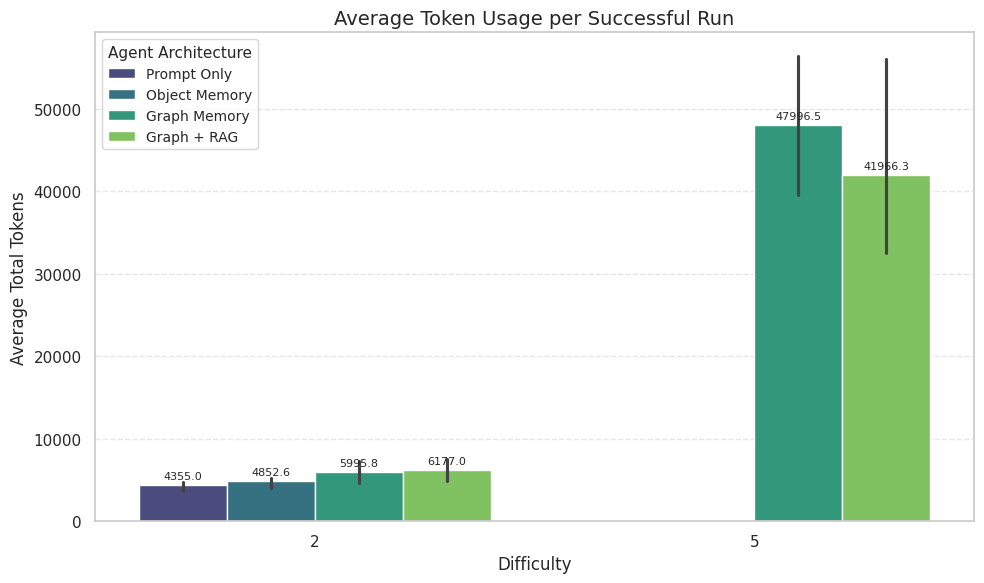

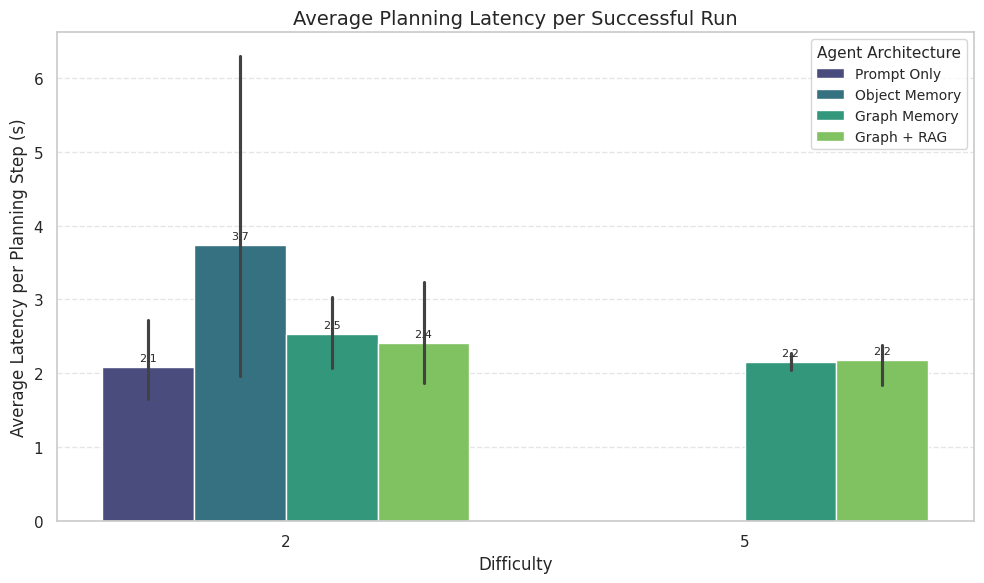

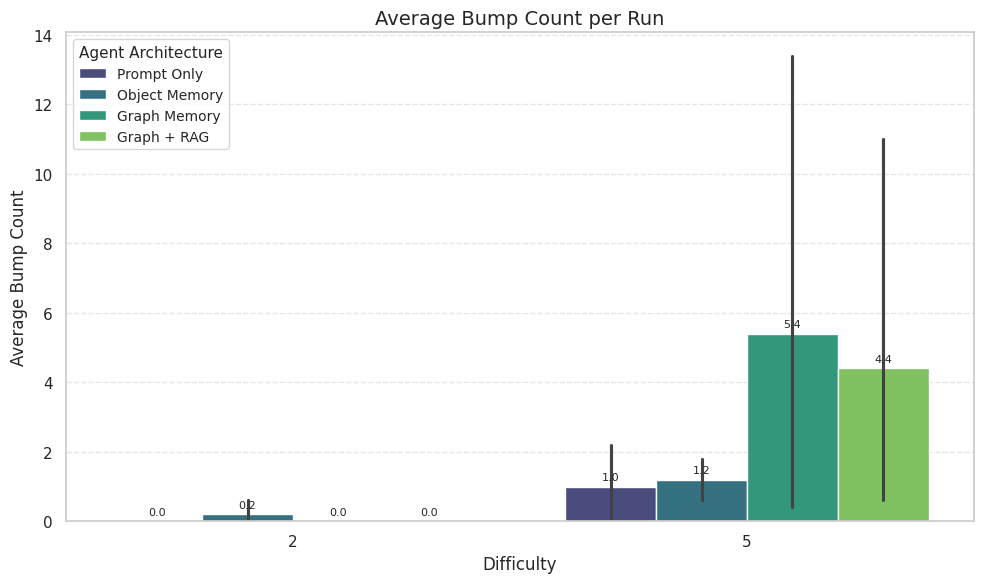

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_tasks = data['tasks'].copy()
df_steps = data['steps'].copy()

selected_cases = [2, 5]

method_order = [
    'prompt_only',
    'prompt_memory',
    'prompt_memory_graph',
    'prompt_memory_graph_rag'
]

method_labels = {
    'prompt_only': 'Prompt Only',
    'prompt_memory': 'Object Memory',
    'prompt_memory_graph': 'Graph Memory',
    'prompt_memory_graph_rag': 'Graph + RAG'
}

plot_order = [method_labels[m] for m in method_order]

df_tasks['Method'] = df_tasks['methodName'].map(method_labels)
df_steps = df_steps.merge(
    df_tasks[['runId', 'methodName', 'Method', 'experimentCaseId', 'success']],
    on='runId',
    how='left'
)

df_tasks_sel = df_tasks[df_tasks['experimentCaseId'].isin(selected_cases)].copy()
df_steps_sel = df_steps[df_steps['experimentCaseId'].isin(selected_cases)].copy()

step_run_metrics = df_steps_sel.groupby('runId').agg(
    totalPromptTokens=('promptTokens', 'sum'),
    totalCompletionTokens=('completionTokens', 'sum'),
    totalTokens=('totalTokens', 'sum'),
    totalApiLatencySeconds=('apiLatencySeconds', 'sum'),
    totalRagLatencySeconds=('ragLatencySeconds', 'sum'),
    avgApiLatencySeconds=('apiLatencySeconds', 'mean'),
    avgRagLatencySeconds=('ragLatencySeconds', 'mean')
).reset_index()

step_run_metrics['totalPlanningLatencySeconds'] = (
    step_run_metrics['totalApiLatencySeconds'] +
    step_run_metrics['totalRagLatencySeconds']
)

step_run_metrics['avgPlanningLatencySeconds'] = (
    step_run_metrics['avgApiLatencySeconds'] +
    step_run_metrics['avgRagLatencySeconds']
)

df_eff = df_tasks_sel.merge(step_run_metrics, on='runId', how='left')

df_success = df_eff[df_eff['success'] == True].copy()

def plot_efficiency_bar(df, metric, ylabel, title, filename, successful_only=True):
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df,
        x='experimentCaseId',
        y=metric,
        hue='Method',
        hue_order=plot_order,
        palette='viridis',
        errorbar=('ci', 95)
    )

    plt.title(title, fontsize=14)
    plt.xlabel('Difficulty', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(title='Agent Architecture', fontsize=10, title_fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=8, padding=3)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

plot_efficiency_bar(
    df_success,
    metric='apiCalls',
    ylabel='Average API Calls',
    title='Average API Calls per Successful Run',
    filename='efficiency_api_calls_difficulty_2_5.png'
)

plot_efficiency_bar(
    df_success,
    metric='totalTokens',
    ylabel='Average Total Tokens',
    title='Average Token Usage per Successful Run',
    filename='efficiency_tokens_difficulty_2_5.png'
)

plot_efficiency_bar(
    df_success,
    metric='avgPlanningLatencySeconds',
    ylabel='Average Latency per Planning Step (s)',
    title='Average Planning Latency per Successful Run',
    filename='efficiency_latency_difficulty_2_5.png'
)

plot_efficiency_bar(
    df_eff,
    metric='bumpCount',
    ylabel='Average Bump Count',
    title='Average Bump Count per Run',
    filename='efficiency_bumps_difficulty_2_5.png',
    successful_only=False
)

/tmp/ipykernel_4278/202096126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4278/202096126.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


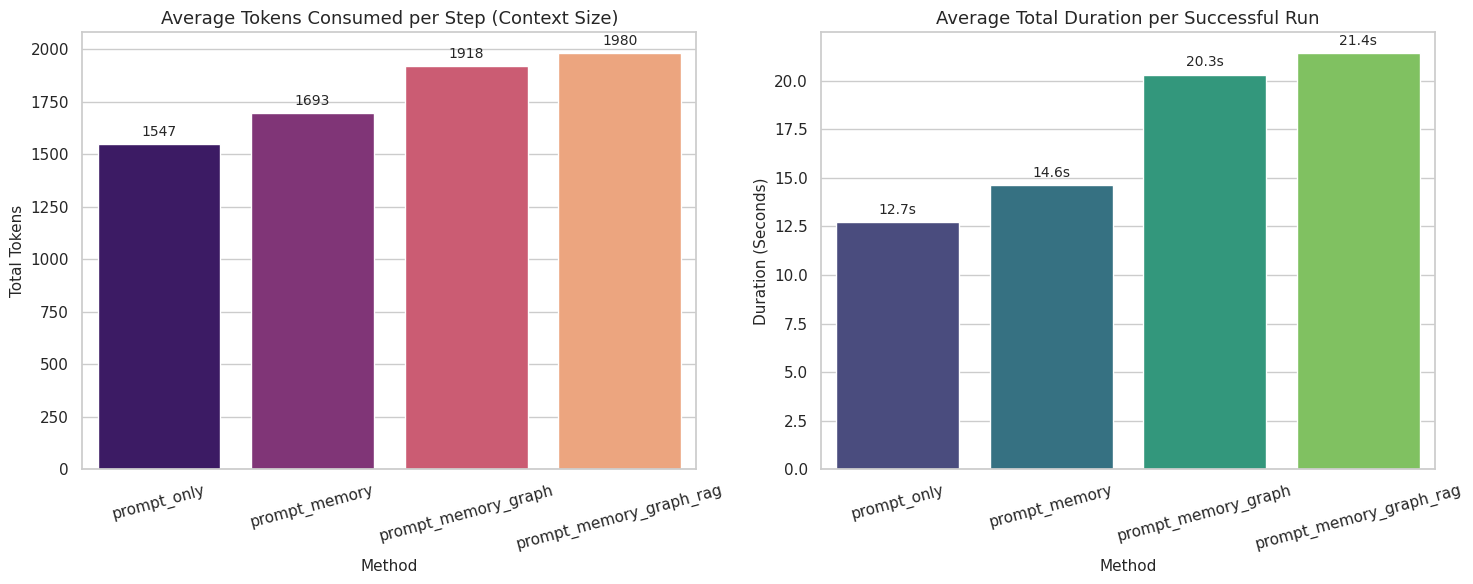

In [6]:
df_tasks = data['tasks']
df_steps = data['steps']

df_steps_merged = df_steps.merge(df_tasks[['runId', 'methodName']], on='runId')

method_order = [
    'prompt_only',
    'prompt_memory',
    'prompt_memory_graph',
    'prompt_memory_graph_rag'
]

tokens_per_step = df_steps_merged.groupby('methodName')['totalTokens'].mean().reindex(method_order).reset_index()

df_success = df_tasks[df_tasks['success'] == True]
duration_per_run = df_success.groupby('methodName')['durationSeconds'].mean().reindex(method_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=tokens_per_step,
    x='methodName',
    y='totalTokens',
    ax=axes[0],
    palette='magma'
)
axes[0].set_title('Average Tokens Consumed per Step (Context Size)', fontsize=13)
axes[0].set_ylabel('Total Tokens', fontsize=11)
axes[0].set_xlabel('Method', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10)

sns.barplot(
    data=duration_per_run,
    x='methodName',
    y='durationSeconds',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Average Total Duration per Successful Run', fontsize=13)
axes[1].set_ylabel('Duration (Seconds)', fontsize=11)
axes[1].set_xlabel('Method', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}s",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np

local_tasks = pd.read_csv("task_results.csv")
local_steps = pd.read_csv("ai_step_log.csv")

df_tasks_all = data["tasks"].copy()
df_steps_all = data["steps"].copy()

df_tasks_all = pd.concat([df_tasks_all, local_tasks], ignore_index=True)
df_steps_all = pd.concat([df_steps_all, local_steps], ignore_index=True)

df_tasks_all["success"] = df_tasks_all["success"].astype(str).str.lower().eq("true")
df_steps_all["apiSucceeded"] = df_steps_all["apiSucceeded"].astype(str).str.lower().eq("true")

In [9]:
methods_to_compare = ["prompt_memory_graph_rag", "local_bc"]

method_labels = {
    "prompt_memory_graph_rag": "Graph + RAG",
    "local_bc": "Local BC"
}

task2_tasks = df_tasks_all[
    (df_tasks_all["experimentCaseId"] == 2) &
    (df_tasks_all["methodName"].isin(methods_to_compare))
].copy()

task2_steps = df_steps_all[
    df_steps_all["runId"].isin(task2_tasks["runId"])
].copy()

seed_counts = task2_tasks.groupby("seed")["methodName"].nunique()
common_seeds = seed_counts[seed_counts == len(methods_to_compare)].index.tolist()

task2_tasks = task2_tasks[task2_tasks["seed"].isin(common_seeds)].copy()
task2_steps = task2_steps[task2_steps["runId"].isin(task2_tasks["runId"])].copy()

run_step_metrics = task2_steps.groupby("runId").agg(
    totalActions=("actionCount", "sum"),
    avgLatencyPerCall=("apiLatencySeconds", "mean"),
    totalPlanningLatency=("apiLatencySeconds", "sum"),
    totalTokens=("totalTokens", "sum"),
    totalPromptTokens=("promptTokens", "sum"),
    totalCompletionTokens=("completionTokens", "sum")
).reset_index()

task2_compare = task2_tasks.merge(run_step_metrics, on="runId", how="left")

task2_compare["Agent"] = task2_compare["methodName"].map(method_labels)

task2_compare[[
    "runId", "seed", "Agent", "success", "apiCalls", "stepsTaken",
    "totalActions", "bumpCount", "avgLatencyPerCall",
    "durationSeconds", "totalTokens"
]]

,runId,seed,Agent,success,apiCalls,stepsTaken,totalActions,bumpCount,avgLatencyPerCall,durationSeconds,totalTokens
0,20260607_161744_228_seed101_case2_prompt_memor...,101,Graph + RAG,True,3,3,9,0,3.684333,14.45,6240
1,20260607_161810_763_seed102_case2_prompt_memor...,102,Graph + RAG,True,3,3,6,0,1.671667,7.30,6218
2,20260607_162220_421_seed106_case2_prompt_memor...,106,Graph + RAG,True,2,2,5,0,1.777500,5.36,3872
3,20260607_162242_340_seed107_case2_prompt_memor...,107,Graph + RAG,True,4,4,7,0,1.677000,9.38,8330
4,20260607_162605_875_seed109_case2_prompt_memor...,109,Graph + RAG,True,3,3,8,0,2.152333,9.03,6225
5,20260616_195509_313_seed101_case2_local_bc,101,Local BC,True,13,13,13,0,2.159615,31.94,0
6,20260616_195613_567_seed102_case2_local_bc,102,Local BC,True,7,7,7,0,2.137714,17.29,0
7,20260616_195646_552_seed106_case2_local_bc,106,Local BC,True,6,6,6,0,1.923333,13.60,0
8,20260616_195708_016_seed107_case2_local_bc,107,Local BC,True,13,13,13,6,2.106385,31.65,0
9,20260616_195747_672_seed109_case2_local_bc,109,Local BC,True,15,15,15,5,2.132600,36.68,0


In [10]:
summary = task2_compare.groupby("Agent").agg(
    Runs=("runId", "count"),
    SuccessRate=("success", lambda x: x.mean() * 100),
    AvgActions=("totalActions", "mean"),
    AvgModelCalls=("apiCalls", "mean"),
    AvgBumps=("bumpCount", "mean"),
    AvgLatencyPerCall=("avgLatencyPerCall", "mean"),
    AvgDuration=("durationSeconds", "mean"),
    AvgTokens=("totalTokens", "mean")
).reset_index()

summary

,Agent,Runs,SuccessRate,AvgActions,AvgModelCalls,AvgBumps,AvgLatencyPerCall,AvgDuration,AvgTokens
0,Graph + RAG,5,100.0,7.0,3.0,0.0,2.192567,9.104,6177.0
1,Local BC,5,100.0,10.8,10.8,2.2,2.091930,26.232,0.0


/tmp/ipykernel_4278/3849568542.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4278/3849568542.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4278/3849568542.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4278/3849568542.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


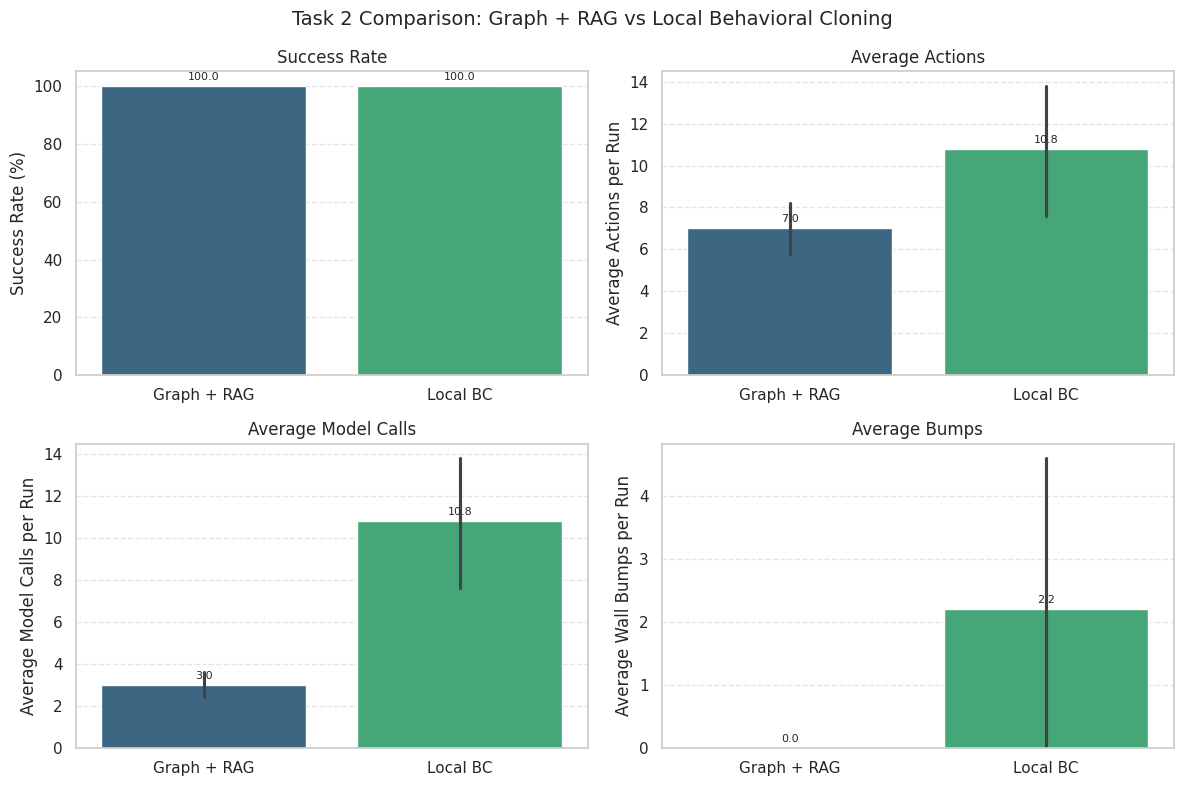

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = task2_compare.copy()

metric_specs = [
    ("success", "Success Rate", "Success Rate (%)"),
    ("totalActions", "Average Actions", "Average Actions per Run"),
    ("apiCalls", "Average Model Calls", "Average Model Calls per Run"),
    ("bumpCount", "Average Bumps", "Average Wall Bumps per Run"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

order = ["Graph + RAG", "Local BC"]

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    if metric == "success":
        temp = plot_data.groupby("Agent")["success"].mean().reset_index()
        temp["success"] = temp["success"] * 100

        sns.barplot(
            data=temp,
            x="Agent",
            y="success",
            order=order,
            ax=ax,
            palette="viridis"
        )
        ax.set_ylim(0, 105)
    else:
        sns.barplot(
            data=plot_data,
            x="Agent",
            y=metric,
            order=order,
            ax=ax,
            palette="viridis",
            errorbar=("ci", 95)
        )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=8, padding=3)

plt.suptitle("Task 2 Comparison: Graph + RAG vs Local Behavioral Cloning", fontsize=14)
plt.tight_layout()
plt.savefig("local_bc_task2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()